# Housing Price Prediction 

### 1. Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv('Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
data.shape

(545, 13)

In [4]:
data.info

<bound method DataFrame.info of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no

In [5]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### 2. Data Cleaning
Checking for nulls and duplicates, then handling them.

In [6]:
# Checking for missing values
print("Null values:\n", data.isnull().sum())

# Checking and removing duplicates
print("\nDuplicates found:", data.duplicated().sum())
data.drop_duplicates(inplace=True)

Null values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicates found: 0


### 3. Preprocessing & Encoding
Converting categorical text into numerical values.

In [7]:
# Binary encoding for yes/no columns
le = LabelEncoder()
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# One-Hot Encoding for furnishingstatus (avoiding dummy variable trap)
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True, dtype=int)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


<Axes: >

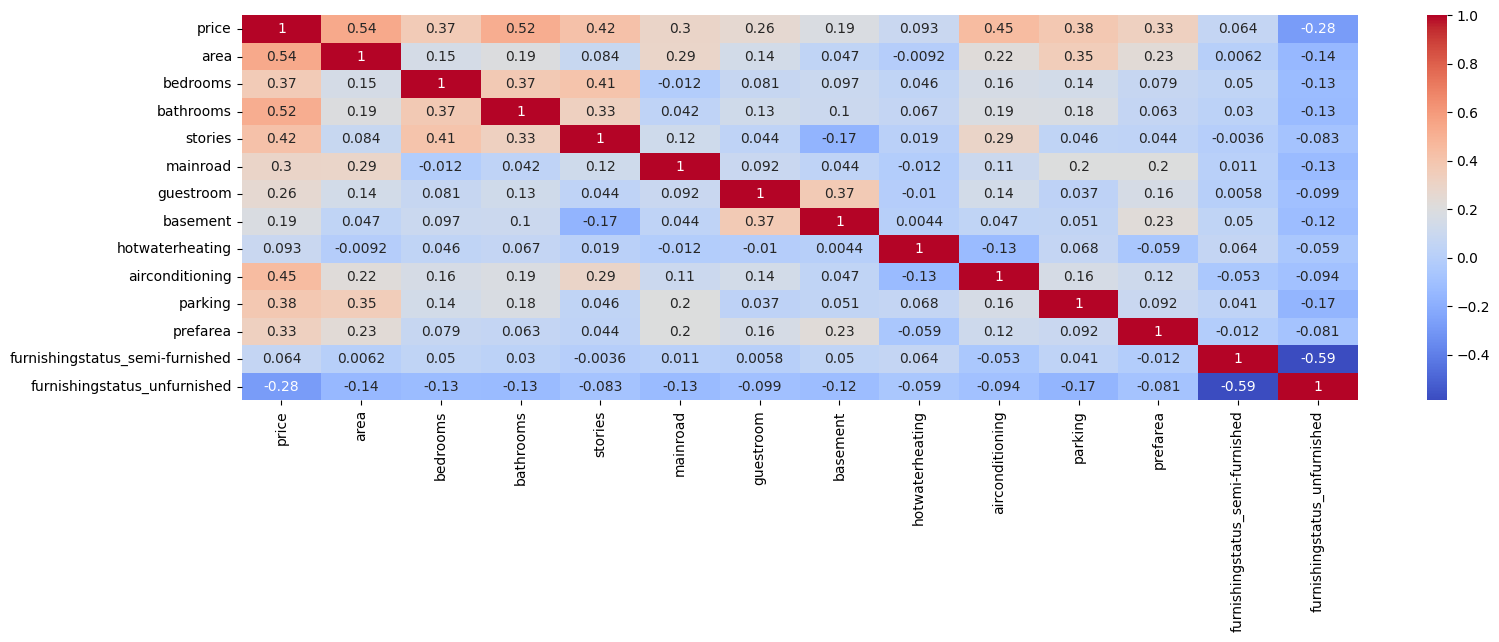

In [8]:
plt.figure(figsize=(18,5))
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap = "coolwarm")

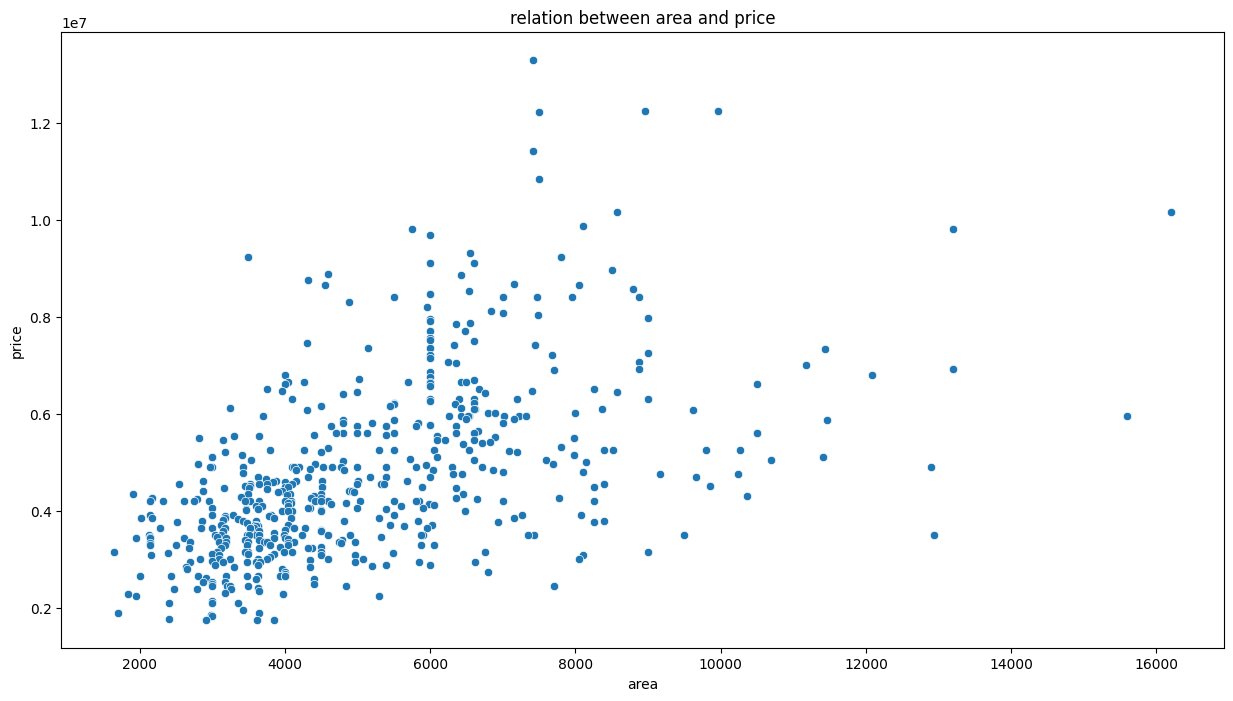

In [9]:
plt.figure(figsize = (15,8))
sns.scatterplot(data=data ,x='area', y = 'price')
plt.title('relation between area and price')
plt.show()

In [10]:
cols_to_drop = ['hotwaterheating','basement','guestroom','furnishingstatus_unfurnished','furnishingstatus_semi-furnished']
data = data.drop(cols_to_drop, axis = 1)

In [11]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'airconditioning', 'parking', 'prefarea'],
      dtype='object')

<Axes: >

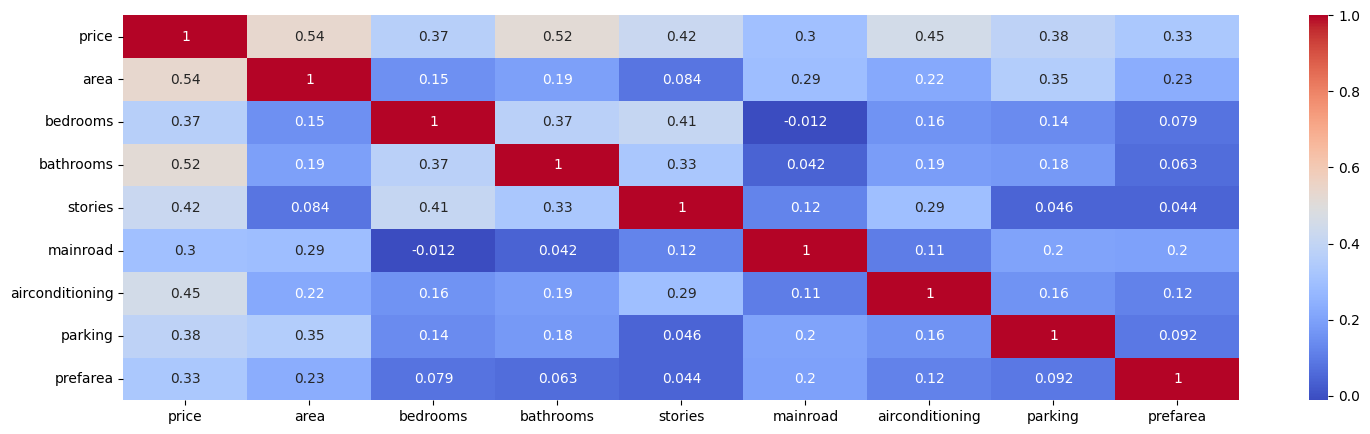

In [12]:
plt.figure(figsize=(18,5))
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap = "coolwarm")

In [13]:
top_features = ['area','bathrooms','airconditioning','stories']

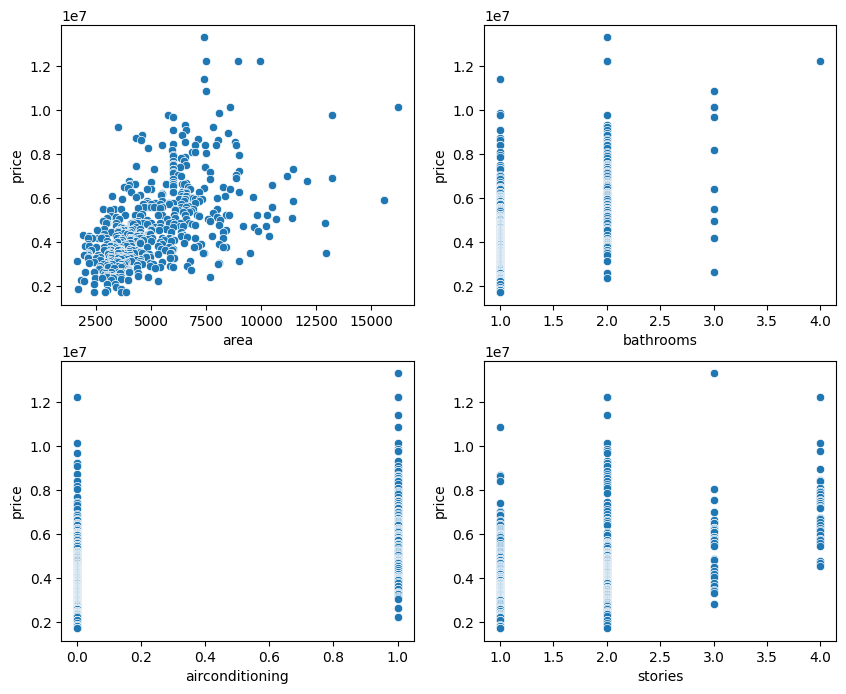

In [14]:
fig, axes = plt.subplots(2, 2,figsize=(10, 8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    if data[col].dtype in ['int64','float64']:
        sns.scatterplot(x=data[col],y=data['price'],ax=axes[i])
    else:
        sns.boxplot(x=data[col],y=data['price'],ax=axes[i])
        axes[i].set_title(f'{col} vs Price')
        axes[i].set_xlabel()

### 4. Feature Engineering
Creating the 'luxury' feature and handling outliers/skewness.

In [15]:
# Creating luxury feature
data['luxury'] = data['airconditioning'] + data['prefarea'] + data['parking']

# Handling Skewness in Price and Area using Log Transformation
data['price'] = np.log1p(data['price'])
data['area'] = np.log1p(data['area'])

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,airconditioning,parking,prefarea,luxury
0,16.403275,8.912069,4,2,3,1,1,2,1,4
1,16.321037,9.100637,4,4,4,1,1,3,0,4
2,16.321037,9.206433,3,2,2,1,0,2,1,3
3,16.318175,8.922792,4,2,2,1,1,3,1,5
4,16.250001,8.912069,4,1,2,1,1,2,0,3


### 5. EDA
Visualizing correlations after cleaning.

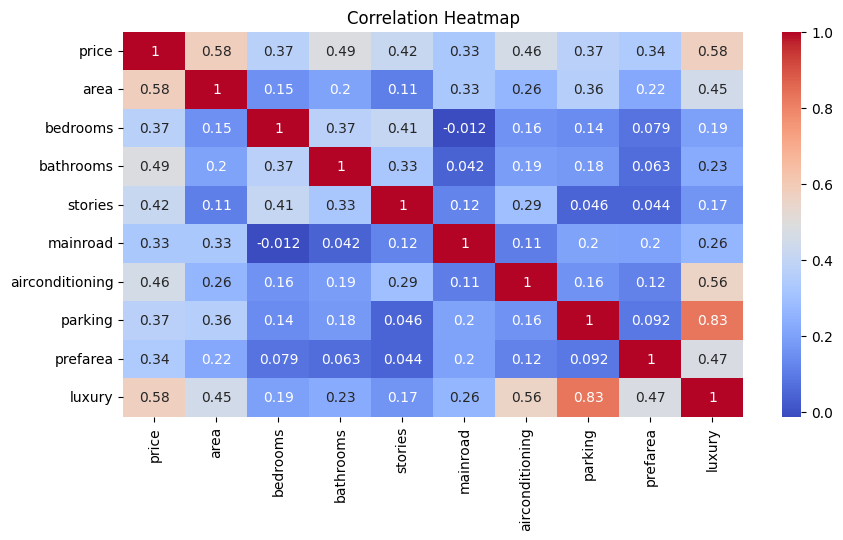

In [16]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 6. Train-Test Split & Scaling
Scaling is essential for Linear Regression.

In [17]:
X = data.drop('price', axis=1)
y = data['price']

In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,airconditioning,parking,prefarea,luxury
0,16.403275,8.912069,4,2,3,1,1,2,1,4
1,16.321037,9.100637,4,4,4,1,1,3,0,4
2,16.321037,9.206433,3,2,2,1,0,2,1,3
3,16.318175,8.922792,4,2,2,1,1,3,1,5
4,16.250001,8.912069,4,1,2,1,1,2,0,3
...,...,...,...,...,...,...,...,...,...,...
540,14.414348,8.006701,2,1,1,1,0,2,0,2
541,14.384879,7.783641,3,1,1,0,0,0,0,0
542,14.375127,8.194506,2,1,1,1,0,0,0,0
543,14.375127,7.976252,3,1,1,0,0,0,0,0


In [21]:
X_train_scaled

array([[ 0.58587975,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  0.65860146],
       [ 1.04444467,  0.05527092,  1.53917323, ...,  2.70998729,
        -0.55262032,  2.36275715],
       [-0.55229895, -1.28351359, -0.5579503 , ...,  1.53897197,
        -0.55262032,  1.5106793 ],
       ...,
       [-0.13765252,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032, -0.19347639],
       [-0.40884496, -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032, -1.04555424],
       [ 0.3670384 ,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  0.65860146]], shape=(436, 9))

In [22]:
X_test_scaled

array([[ 0.5436081 ,  1.39405543,  1.53917323,  0.25421524, -2.45606557,
        -0.66611456,  0.36795665, -0.55262032, -0.19347639],
       [ 0.78719709,  0.05527092,  1.53917323,  1.42092939,  0.40715525,
         1.50124327, -0.80305867,  1.80956067,  0.65860146],
       [-0.40884496, -1.28351359, -0.5579503 , -0.91249891,  0.40715525,
        -0.66611456, -0.80305867, -0.55262032, -1.04555424],
       [ 0.1273288 ,  0.05527092, -0.5579503 ,  0.25421524,  0.40715525,
         1.50124327, -0.80305867, -0.55262032, -0.19347639],
       [-0.4591446 ,  0.05527092, -0.5579503 , -0.91249891,  0.40715525,
        -0.66611456, -0.80305867, -0.55262032, -1.04555424],
       [ 0.8709162 ,  0.05527092, -0.5579503 , -0.91249891,  0.40715525,
        -0.66611456, -0.80305867, -0.55262032, -1.04555424],
       [ 1.46784256,  0.05527092, -0.5579503 , -0.91249891,  0.40715525,
         1.50124327,  1.53897197, -0.55262032,  1.5106793 ],
       [ 0.12229372,  1.39405543,  1.53917323,  0.25421524,  0

In [23]:
print("Shape of X_train:", X_train_scaled.shape)

Shape of X_train: (436, 9)


### 7. Model Training & Evaluation

In [24]:
model = LinearRegression()

In [25]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# Predictions
y_pred = model.predict(X_test_scaled)

In [27]:
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.6269890535435962
Mean Squared Error: 0.07202417674089992


RANDOM FOREST

In [28]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [29]:
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
rf_pred = rf_model.predict(X_test_scaled)


In [31]:
print("Random Forest Results:")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))

Random Forest Results:
R2 Score: 0.6080572278499088
MSE: 0.07567969723632705


In [32]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)


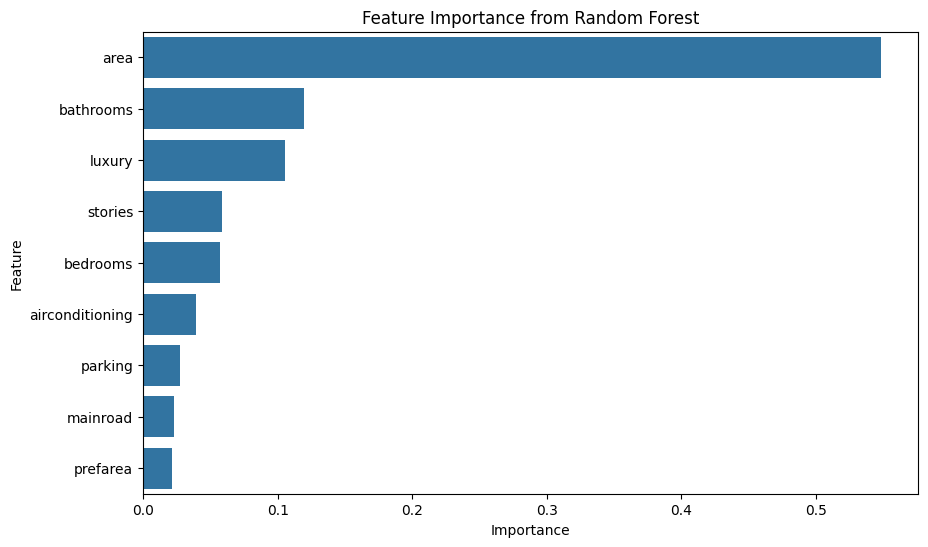

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest')
plt.show()